# Customer Churn Prediction with Digit Decomposition and Optuna

This notebook builds a churn prediction model using the dataset from the Kaggle competition.

Key techniques explored:
- Digit decomposition for numeric features
- Hyperparameter tuning with Optuna
- Feature importance analysis using XGBoost

The goal is to test whether digit-level numerical representations can improve model performance in tree-based models.

## Importing Data:

In [1]:
import pandas as pd

train_path = '/kaggle/input/competitions/playground-series-s6e3/train.csv'
test_path = '/kaggle/input/competitions/playground-series-s6e3/test.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print('Train Shape:', train_df.shape)
display(train_df.head(3))
print('Test Shape:', test_df.shape)
display(test_df.head(3))

Train Shape: (594194, 21)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.1,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.5,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.4,5841.35,No


Test Shape: (254655, 20)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,594194,Female,0,Yes,No,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,115.55,8061.50
1,594195,Female,0,Yes,No,71,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),19.80,1336.50
2,594196,Male,0,No,No,12,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),55.55,633.55


In [2]:
target = 'Churn'

cat_cols = ['gender','Partner', 'Dependents', 'SeniorCitizen',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',] 

num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

In [3]:
train_df[target] = train_df[target].map({'No': 0, 'Yes': 1})

## Feature Engineering:

In [4]:
combined_df = pd.concat([train_df,test_df], axis=0, ignore_index=True)

### Digit Decomposition:
It breaks numeric values into individual digits and uses each digit as a separate feature. This technique is sometimes used in tree models.The idea of digit decomposition for numerical features was inspired by another public notebook in the competition. I experimented with this technique and integrated it into my own pipeline to evaluate its impact on model performance.

This will be applied to the num_cols, the idea of using digit decomposition came from

In [5]:
import numpy as np

digit_cols = []

for col in num_cols:
    max_val = combined_df[col].abs().max()

    #conditional 1:
    if max_val == 0:
        digit_count = 1
    else:
      digit_count = int(np.log10(max_val)) + 1  

    for i in range(digit_count):
        new_col = f"{col}_digit_pos_{i+1}"

        combined_df[new_col] = (combined_df[col] // (10**i)) % 10
        combined_df[new_col] = combined_df[new_col].astype(int)

        digit_cols.append(new_col)

    #conditional 2:
    if combined_df[col].dtype == 'float64':
        max_dec_count = 2

        if (combined_df[col] % 1 != 0).any():
            for i in range(1, max_dec_count + 1):
                new_col = f"{col}_digit_dec_{i}"
                
                combined_df[new_col] = (combined_df[col] * (10**i)).round().astype(int) % 10
                
                digit_cols.append(new_col)

In [6]:
print('Newly created digit_cols are as follows: \n',digit_cols)

Newly created digit_cols are as follows: 
 ['tenure_digit_pos_1', 'tenure_digit_pos_2', 'MonthlyCharges_digit_pos_1', 'MonthlyCharges_digit_pos_2', 'MonthlyCharges_digit_pos_3', 'MonthlyCharges_digit_dec_1', 'MonthlyCharges_digit_dec_2', 'TotalCharges_digit_pos_1', 'TotalCharges_digit_pos_2', 'TotalCharges_digit_pos_3', 'TotalCharges_digit_pos_4', 'TotalCharges_digit_dec_1', 'TotalCharges_digit_dec_2']


**Explaination**:
* **Conditional 1:**
      Seperates the digits before decimal point into diffrent columns on the basisi of there respective positioning.
* **Conditional 2:**
      Does the same thing but for the digits after the decimal point.

I tried adding features like:
* Binning
* GroupMean Encoding
* Freq Encoding

But they were adding noise all-together than helping get closer to good predictions, so they were kept on halt and not used alongside digit decomposition.

In [7]:
for col in cat_cols:
    combined_df[col] = combined_df[col].astype(str).astype('category')

In [8]:
train_df = combined_df.iloc[: len(train_df)].reset_index(drop=True)
test_df  = combined_df.iloc[len(train_df) :].reset_index(drop=True)

## Optuna Tuning:
Optuna helps us find best hyperparameters for our model with respect to our current preprocessing pipeline and feature space, given the range/grid of hyperparameters. Its better than GridSearchCV since it deosnt try all possible values insted tries some specific values which it thinks will yield good results saves processing time and expense for all different trials that we would have had to go through using gridsearch.

In [9]:
features = cat_cols + num_cols + digit_cols

In [10]:
X = train_df[features] #final train data
y = train_df[target]

X_test = test_df[features] #final test data

XGBoost is being used here as a choice of model, the reasion being it performed the best in baseline modeling results.

In [11]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

def objective(trial):
    params = {
        # Core learning parameters
        "n_estimators": trial.suggest_int("n_estimators", 500, 3500),
        "learning_rate": trial.suggest_float("learning_rate", 0.005, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        
        # Tree complexity control
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "gamma": trial.suggest_float("gamma", 0, 5),
        
        # Sampling 
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.3, 1.0),
        
        # Regularization 
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),

        # Performance
        "random_state": 42,
        "eval_metric": "logloss",
        "tree_method": "hist",   
        "verbosity": 0,
        "device":'cuda',
        "enable_categorical":True
    }

    model = XGBClassifier(**params)

    score = cross_val_score(model, X, y, cv=5, scoring='roc_auc').mean()

    return score

In [12]:
# study = optuna.create_study(direction='maximize')
# study.optimize(objective, n_trials=65)

In [13]:
# print(study.best_params)
# print(study.best_value)

* **best_params_set** = {'n_estimators': 2500, 'learning_rate': 0.021343076630791043, 'max_depth': 6, 'min_child_weight': 7, 'gamma': 0.861751498622332, 'subsample': 0.8551145690799331, 'colsample_bytree': 0.6623034984700539, 'reg_alpha': 0.019334069196449158, 'reg_lambda': 6.572714277172166}
* **best_cv_score** = 0.9179758298561163

In [14]:
best_xgb_params = {'n_estimators': 2500,
                   'learning_rate': 0.021343076630791043,
                   'max_depth': 6,
                   'min_child_weight': 7,
                   'gamma': 0.861751498622332, 
                   'subsample': 0.8551145690799331,
                   'colsample_bytree': 0.6623034984700539,
                   'reg_alpha': 0.019334069196449158,
                   'reg_lambda': 6.572714277172166}

## Checking Feature Importance:
Training a model on full training data to get an idea about which features are contributing the most, also to check if out newly created features are useful or not.

In [15]:
model = XGBClassifier(
    **best_xgb_params,
    random_state= 42,
    eval_metric= "logloss",
    tree_method= "hist",   
    verbosity= 0,
    device= 'cuda',
    enable_categorical= True
)

model.fit(X,y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.6623034984700539, device='cuda',
              early_stopping_rounds=None, enable_categorical=True,
              eval_metric='logloss', feature_types=None, feature_weights=None,
              gamma=0.861751498622332, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.021343076630791043,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=7, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=2500, n_jobs=None,
              num_parallel_tree=None, ...)

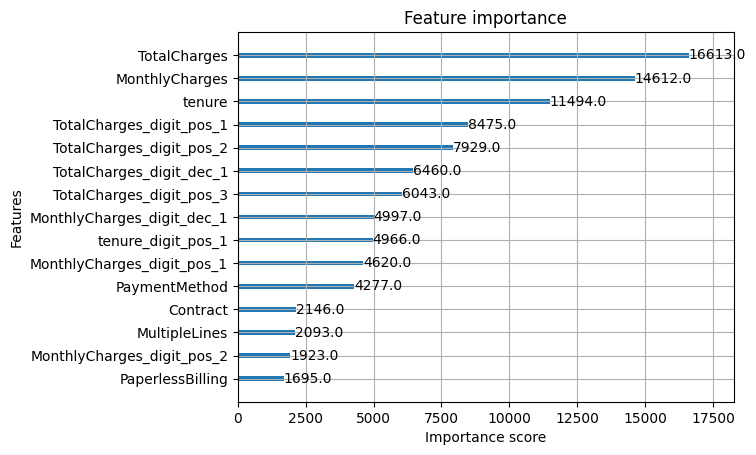

In [16]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model, max_num_features=15)
plt.show()

The feature importance plot shows that several digit-decomposed features are being utilized by the model, suggesting that the transformation may provide additional useful signals.

In [17]:
y_pred = model.predict_proba(X_test)[:,1]

In [18]:
submission = pd.DataFrame({
    'id': test_df['id'],
    target: y_pred 
})

submission.to_csv('submission.csv', index= False)